In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# LOAD DATASET
def load_dataset():
    train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
    test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")

    
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])

    test_set_x_orig = np.array(test_dataset["test_set_x"][:])
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


In [3]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

print("Train X shape:", train_set_x_orig.shape)
print("Train Y shape:", train_set_y.shape)

print("Test X shape:", test_set_x_orig.shape)
print("Test Y shape:", test_set_y.shape)


Train X shape: (209, 64, 64, 3)
Train Y shape: (1, 209)
Test X shape: (50, 64, 64, 3)
Test Y shape: (1, 50)


In [4]:
print(train_set_x_orig.ndim,"D")
print(train_set_y.ndim,"D")


4 D
2 D


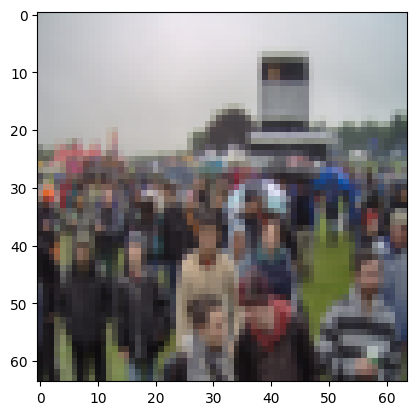

Label: 0


In [5]:
index = 100
plt.imshow(train_set_x_orig[index])
plt.show()
print("Label:", train_set_y[0, index])

In [6]:
#flatten img
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

print("Flatten train shape:", train_set_x_flatten.shape)
print("Flatten test shape:", test_set_x_flatten.shape)


Flatten train shape: (12288, 209)
Flatten test shape: (12288, 50)


In [7]:
# NORMALIZATION
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

In [8]:
#initialize param
def initialize(layer_dims):
    np.random.seed(1)
    parameters={}
    for l in range(1,len(layer_dims)):
        parameters["w" +str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])*0.01
        parameters["b" +str(l)]=np.zeros((layer_dims[l] ,1))

    return parameters

In [9]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [10]:
def relu(z):
    return np.maximum(0,z)

In [11]:
def relu_deri(A):
     return (A > 0).astype(float)

In [12]:
#prop
def propagation(X,Y,layer_dims,parameters):
    Z_values={}
    A_values=[X]
    m=X.shape[1]
    dz_values={}
    dw_values={}
    db_values={}
    da_values={}
    for i in range(0,(len(layer_dims)-2)):
        Z_values["Z" +str(i+1)]=np.dot(parameters["w"+str(i+1)], A_values[i] )+parameters["b"+str(i+1)]
        A=relu(Z_values["Z" +str(i+1)])
        A_values.append(A)

    Z_values["Z" +str(len(layer_dims)-1)]=np.dot(parameters["w"+str(len(layer_dims)-1)], A_values[-1] )+parameters["b"+str(len(layer_dims)-1)]
    A_final=sigmoid(Z_values["Z" +str(len(layer_dims)-1)])
  
    cost= - (1/m) * np.sum(
        Y * np.log(A_final + 1e-8) +
        (1 - Y) * np.log(1 - A_final + 1e-8)
    )

    dz_values["dZ"+str(len(layer_dims)-1)]=A_final-Y
    dw_values["dw"+str(len(layer_dims)-1)]=1/m*(np.dot(dz_values["dZ" +str(len(layer_dims)-1)],A_values[-1].T))
    db_values["db"+str(len(layer_dims)-1)]=1/m*np.sum(dz_values["dZ" +str(len(layer_dims)-1)], axis=1, keepdims=True)
    da_values["da"+str(len(layer_dims)-2)]=np.dot(parameters["w"+str(len(layer_dims)-1)].T,dz_values["dZ"+str(len(layer_dims)-1)])
    
    for i in range((len(layer_dims)-2),0,-1):
         dz_values["dZ"+str(i)] = da_values["da"+str(i)] * relu_deri(Z_values["Z"+str(i)])
         dw_values["dw"+str(i)]=1/m*(np.dot(dz_values["dZ"+str(i)],A_values[i-1].T))
         db_values["db"+str(i)]=1/m*np.sum(dz_values["dZ"+str(i)], axis=1, keepdims=True)
         da_values["da"+str(i-1)]=np.dot(parameters["w"+str(i)].T,dz_values["dZ"+str(i)])
   
                                                      
    cost = np.squeeze(cost)

    return dw_values,db_values , cost
    

In [13]:
l = [12288,20,7,5,1]
parameters=initialize(l)
for key in parameters:
    print(key, parameters[key].shape)

w1 (20, 12288)
b1 (20, 1)
w2 (7, 20)
b2 (7, 1)
w3 (5, 7)
b3 (5, 1)
w4 (1, 5)
b4 (1, 1)


In [18]:
#optimization
def optimizer(parameters, X, Y,layer_dims, num_iterations, learning_rate, print_cost=False):
    costs=[]
    for i in range(num_iterations):
        dw_values ,db_values , cost = propagation(X,Y,layer_dims,parameters)

        for j in range(1,len(layer_dims)):
            
            dw= dw_values["dw"+str(j)]
            db= db_values["db"+str(j)]

            # UPDATE PARAMETERS
            parameters["w"+str(j)] = parameters["w"+str(j)] - learning_rate * dw
            parameters["b"+str(j)] = parameters["b"+str(j)] - learning_rate * db
            
        if i % 100 == 0:
            costs.append(cost)

        if print_cost and i % 100 == 0:
            print("Cost after iteration %i: %f" % (i, cost))
    new_dw = dw_values
    new_db= db_values
    for key in parameters:
       print(key, parameters[key].shape)
    return parameters, new_dw,new_db, costs

In [19]:
def predict(w,b,X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))#initially sare pred 0 2D
    w = w.reshape(X.shape[0], 1)#w ko x ka shape mai kiya
    Z = np.dot(w.T, X) + b #zdim =(1, m)
    A = sigmoid(Z)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0

    return Y_prediction  

In [20]:
def model( X_train, Y_train, X_test, Y_test,layer_dims , num_iterations=2000, learning_rate=0.005, print_cost=False):
    parameters = initialize(layer_dims) 
    parameters, new_dw,new_db, costs= optimizer(parameters,X_train,Y_train, layer_dims,num_iterations, learning_rate, print_cost) 
    w=parameters["w"+str(len(layer_dims)-1)] 
    b=parameters["b"+str(len(layer_dims)-1)]
    Y_prediction_test= predict(w,b,X_test)
    Y_prediction_train= predict(w,b,X_train) 
    #accuracy 
    train_accuracy = np.mean(Y_prediction_train == Y_train) * 100
    test_accuracy = np.mean(Y_prediction_test == Y_test) * 100 
    print("Train accuracy: {} %".format(train_accuracy))
    print("Test accuracy: {} %".format(test_accuracy)) 
    d={ "costs": costs,
        "Y_prediction_test": Y_prediction_test, 
        "Y_prediction_train": Y_prediction_train, 
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations }
    return d

In [21]:
layer_dims=[12288,20,7,5,1]
d=model(train_set_x,
        train_set_y,
        test_set_x,
        test_set_y,
        layer_dims,
        num_iterations=200,
        learning_rate=0.005,
        print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.682443
w1 (7, 12288)
b1 (7, 1)
w2 (5, 7)
b2 (5, 1)
w3 (2, 5)
b3 (2, 1)
w4 (1, 2)
b4 (1, 1)


ValueError: cannot reshape array of size 2 into shape (12288,1)